Analyse des disparités salariales par niveau d'emploi
Voici une structure complète et professionnelle pour répondre à ce défi quotidien.
Objectifs de l'analyse :
Identifier les disparités de salaire entre les différents niveaux d'emploi
Voir comment le salaire évolue avec l'expérience
Analyser la répartition des salaires pour les postes de niveau supérieur

In [61]:
import pandas as pd
import numpy as np

# Create dummy data for 'salaries.csv'
data = {
    'experience_level': np.random.choice(['EN', 'MI', 'SE', 'EX'], size=100),
    'salary': np.random.randint(40000, 150000, size=100),
    'years_of_experience': np.random.randint(0, 20, size=100)
}

dummy_salaries_df = pd.DataFrame(data)

# Save the dummy DataFrame to 'salaries.csv'
dummy_salaries_df.to_csv('salaries.csv', index=False)

print("Created dummy 'salaries.csv' file.")

Created dummy 'salaries.csv' file.


Shape: (100, 3)

Niveaux d'emploi uniques : ['SE' 'EX' 'MI' 'EN']

=== Statistiques salariales par niveau d'emploi ===
                  count       mean    median    min     max       std
experience_level                                                     
EN                   30  103046.50  105429.0  48723  147775  24337.68
EX                   20   97397.00  100650.0  43102  147149  35527.79
MI                   23  105311.04  107781.0  51757  133117  23026.76
SE                   27   95949.37   96807.0  40993  145883  36248.58


/tmp/ipykernel_3658/1648011136.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_salaries.index, y=mean_salaries.values, palette='Blues_d')


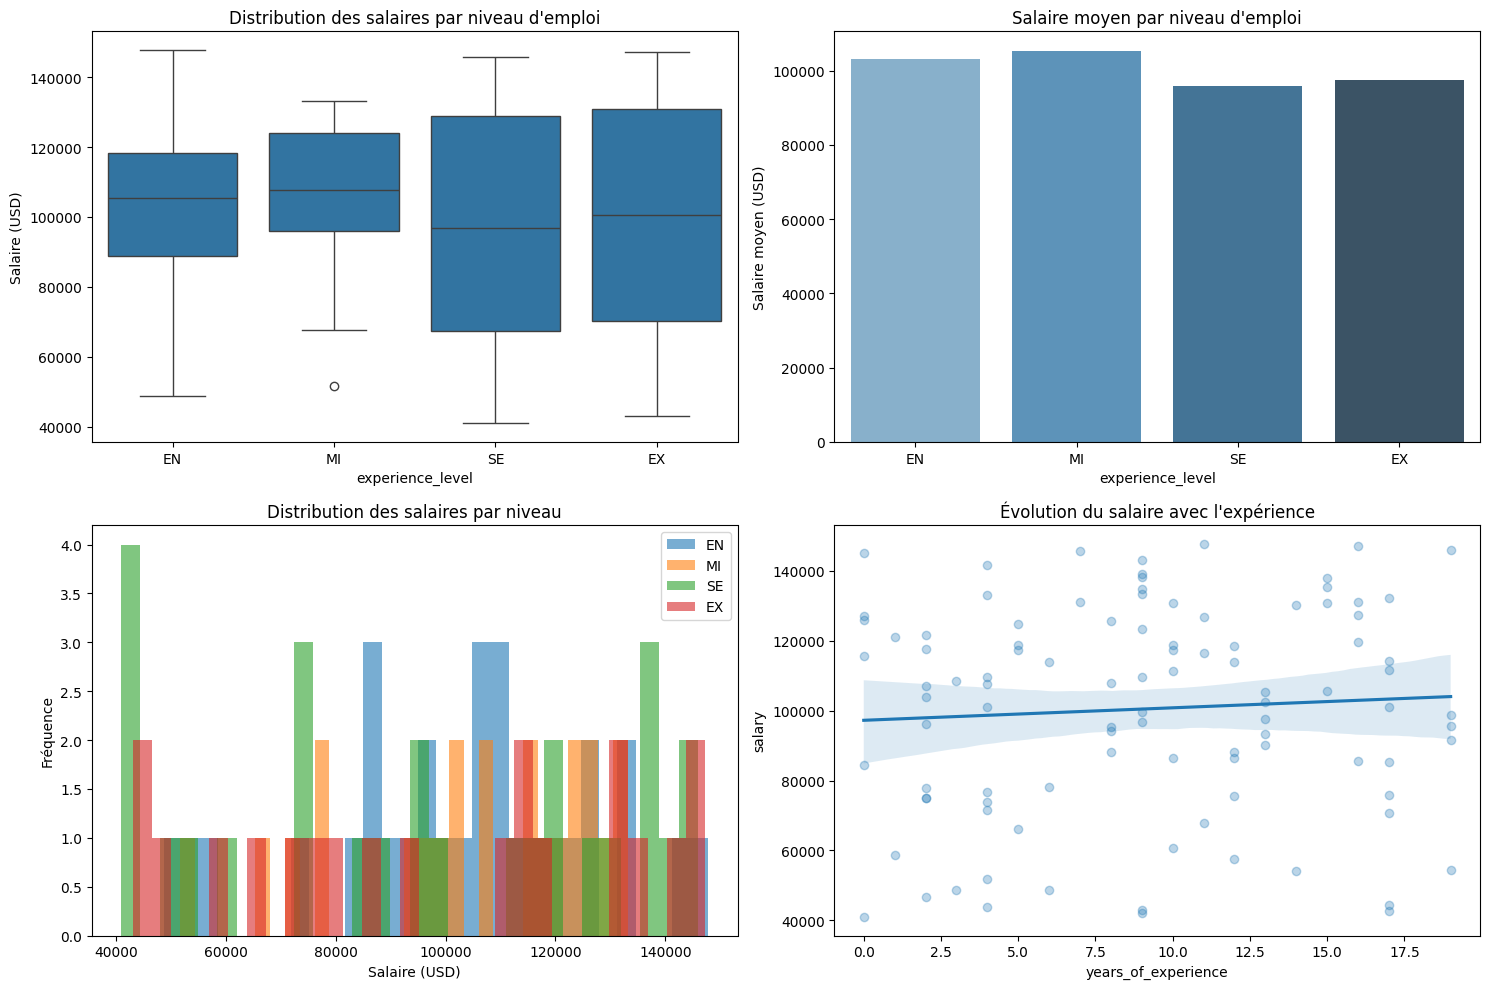

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ====================== CHARGEMENT DES DONNÉES ======================
df = pd.read_csv('salaries.csv')  # Adaptez le nom du fichier

# Nettoyage rapide
print("Shape:", df.shape)
print("\nNiveaux d'emploi uniques :", df['experience_level'].unique())

# ====================== ANALYSE STATISTIQUE ======================
# Statistiques par niveau d'emploi
salary_by_level = df.groupby('experience_level')['salary'].agg([
    'count', 'mean', 'median', 'min', 'max', 'std'
]).round(2)

print("\n=== Statistiques salariales par niveau d'emploi ===")
print(salary_by_level)

# Évolution du salaire moyen par niveau
level_order = ['EN', 'MI', 'SE', 'EX']  # Entry, Mid, Senior, Executive
if set(level_order).issubset(df['experience_level'].unique()):
    salary_by_level = salary_by_level.reindex(level_order)

# ====================== VISUALISATIONS ======================

plt.figure(figsize=(15, 10))

# 1. Boxplot des salaires par niveau
plt.subplot(2, 2, 1)
sns.boxplot(data=df, x='experience_level', y='salary', order=level_order)
plt.title('Distribution des salaires par niveau d\'emploi')
plt.ylabel('Salaire (USD)')

# 2. Barplot du salaire moyen
plt.subplot(2, 2, 2)
mean_salaries = df.groupby('experience_level')['salary'].mean().reindex(level_order)
sns.barplot(x=mean_salaries.index, y=mean_salaries.values, palette='Blues_d')
plt.title('Salaire moyen par niveau d\'emploi')
plt.ylabel('Salaire moyen (USD)')

# 3. Répartition des salaires (histogrammes)
plt.subplot(2, 2, 3)
for level in level_order:
    if level in df['experience_level'].values:
        subset = df[df['experience_level'] == level]['salary']
        plt.hist(subset, alpha=0.6, label=level, bins=30)
plt.title('Distribution des salaires par niveau')
plt.xlabel('Salaire (USD)')
plt.ylabel('Fréquence')
plt.legend()

# 4. Évolution du salaire avec l'expérience (si colonne disponible)
if 'years_of_experience' in df.columns:
    plt.subplot(2, 2, 4)
    sns.regplot(data=df, x='years_of_experience', y='salary', scatter_kws={'alpha':0.3})
    plt.title('Évolution du salaire avec l\'expérience')

plt.tight_layout()
plt.savefig('salary_analysis_by_level.png', dpi=300, bbox_inches='tight')
plt.show()